<h1 align="center"><b>Programming Assignment 1 (100 points total)</b></h1>
<h3 align="center"><b>Unnas Hussain</b></h3><br>


## **Question 1: Exploratory Data Analysis and Preprocessing**

### **Objective**  
In this question, you will conduct a structured exploratory data analysis (EDA) and preprocess the **Wine Quality Dataset** to prepare it for downstream analysis. This includes computing **summary statistics**, detecting and removing **outliers using Mahalanobis distance**, applying **feature normalization**, and performing **dimensionality reduction with PCA**. Throughout, you will be required to analyze your results and justify your methodological choices.

- **Dataset:** [Wine Quality Dataset](https://archive.ics.uci.edu/ml/datasets/Wine+Quality)  
- **Focus Areas:** Algorithm analysis, data interpretation, and preprocessing strategies.


## **Code**

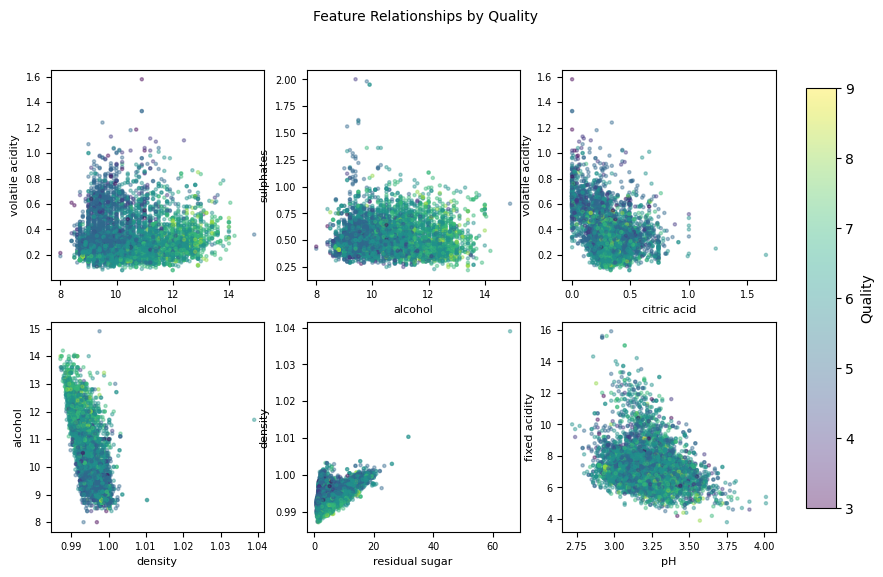

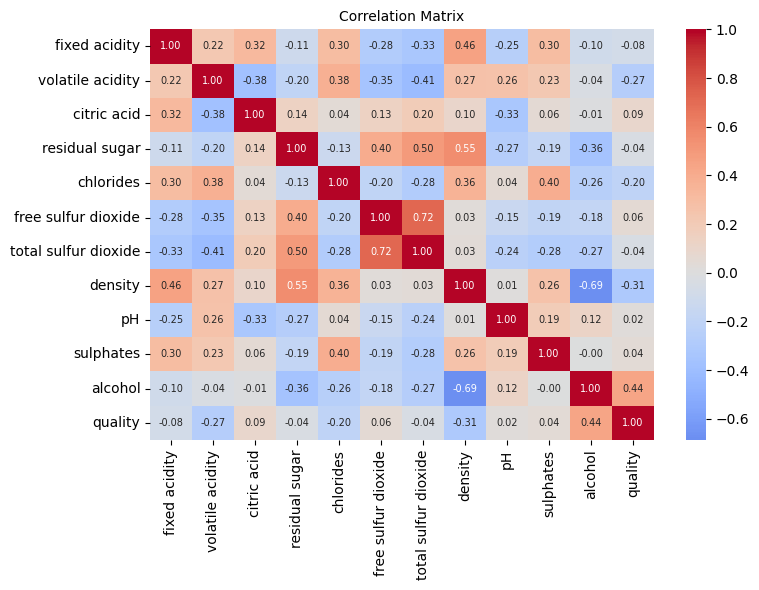

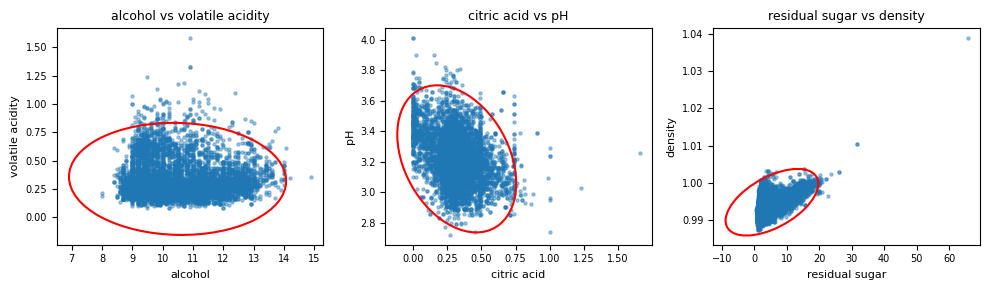

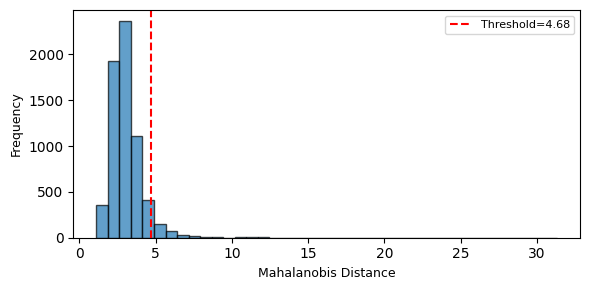

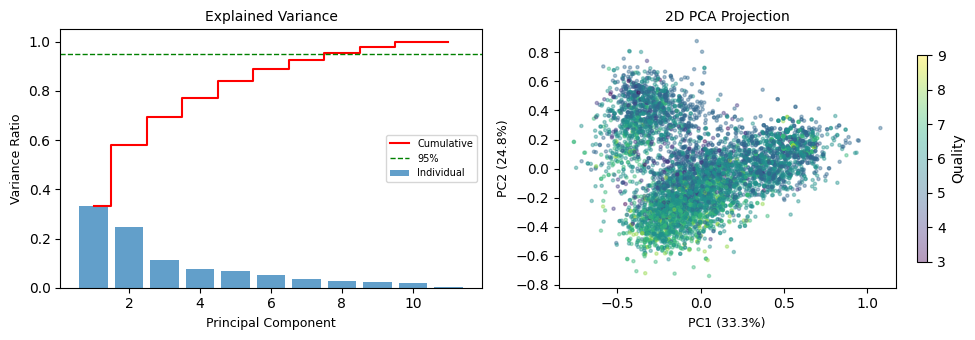

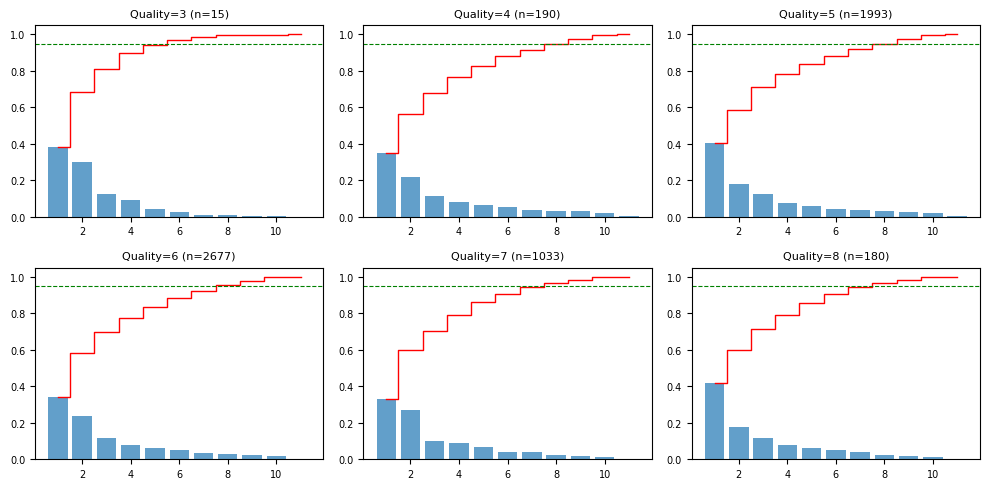

In [33]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.spatial.distance import mahalanobis
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA


class WineDataAnalysis:
    """
    Wine Quality Dataset analysis pipeline.
    Performs EDA, outlier detection, normalization, and PCA.
    """
    
    def __init__(self, verbose=True):
        self.df_raw = None
        self.df_cleaned = None
        self.df_normalized = None
        self.numerical_cols = None
        self.scaler = MinMaxScaler()
        self.pca = None
        self.pca_components = None
        self.verbose = verbose
        
    def load_data(self):
        """Load and combine red/white wine datasets."""
        url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
        url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
        
        df_red = pd.read_csv(url_red, sep=';')
        df_white = pd.read_csv(url_white, sep=';')
        df_red['wine_type'] = 'red'
        df_white['wine_type'] = 'white'
        self.df_raw = pd.concat([df_red, df_white], axis=0, ignore_index=True)
        
        self.numerical_cols = self.df_raw.select_dtypes(include=[np.number]).columns.tolist()
        self.numerical_cols.remove('quality')
        
        if self.verbose:
            print(f"Dataset Shape: {self.df_raw.shape}")
            print(f"Missing Values: {self.df_raw.isnull().sum().sum()}")
        return self.df_raw.head()
    
    # -------------------------------------------------------------------------
    # Part 1: Summary Statistics
    # -------------------------------------------------------------------------
    def compute_summary_stats(self, data, columns):
        """Compute summary statistics for given columns."""
        stats_dict = {}
        for col in columns:
            values = data[col].dropna()
            stats_dict[col] = {
                'Min': values.min(),
                'Max': values.max(),
                'Mean': values.mean(),
                'Trimmed Mean (5%)': stats.trim_mean(values, 0.05),
                'Std Dev': values.std(),
                'Skewness': stats.skew(values),
                'Kurtosis': stats.kurtosis(values)
            }
        return pd.DataFrame(stats_dict).T
    
    def part1_summary_statistics(self):
        """Compute summary statistics (tables presented in Interpretations)."""
        self.overall_stats = self.compute_summary_stats(self.df_raw, self.numerical_cols)
        self.quality_stats = {}
        for quality in sorted(self.df_raw['quality'].unique()):
            subset = self.df_raw[self.df_raw['quality'] == quality]
            self.quality_stats[quality] = self.compute_summary_stats(subset, self.numerical_cols)
        
        if self.verbose:
            print("Part 1: Summary statistics computed.")
        return self.overall_stats
    
    # -------------------------------------------------------------------------
    # Part 2: Data Visualization
    # -------------------------------------------------------------------------
    def part2_visualization(self):
        """Create scatter plots and correlation heatmap."""
        fig, axes = plt.subplots(2, 3, figsize=(10, 6))
        plots = [
            ('alcohol', 'volatile acidity'),
            ('alcohol', 'sulphates'),
            ('citric acid', 'volatile acidity'),
            ('density', 'alcohol'),
            ('residual sugar', 'density'),
            ('pH', 'fixed acidity')
        ]
        
        for ax, (x, y) in zip(axes.flatten(), plots):
            sc = ax.scatter(self.df_raw[x], self.df_raw[y], 
                           c=self.df_raw['quality'], cmap='viridis', alpha=0.4, s=5)
            ax.set_xlabel(x, fontsize=8)
            ax.set_ylabel(y, fontsize=8)
            ax.tick_params(labelsize=7)
        
        fig.subplots_adjust(right=0.85)
        cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
        fig.colorbar(sc, cax=cbar_ax, label='Quality')
        fig.suptitle('Feature Relationships by Quality', fontsize=10)
        plt.show()
        
        fig, ax = plt.subplots(figsize=(8, 6))
        corr = self.df_raw[self.numerical_cols + ['quality']].corr()
        sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
                    annot_kws={'size': 7}, ax=ax)
        ax.set_title('Correlation Matrix', fontsize=10)
        plt.tight_layout()
        plt.show()
        
        if self.verbose:
            print("Part 2: Visualizations generated.")
    
    # -------------------------------------------------------------------------
    # Part 3: Outlier Detection (Mahalanobis Distance)
    # -------------------------------------------------------------------------
    def _plot_ellipse(self, data, f1, f2, ax, n_std=3):
        """Plot scatter with Mahalanobis ellipse boundary."""
        x = data[[f1, f2]].dropna().values
        mean = np.mean(x, axis=0)
        cov = np.cov(x.T)
        
        ax.scatter(x[:, 0], x[:, 1], alpha=0.4, s=5)
        
        eigenvalues, eigenvectors = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width, height = 2 * n_std * np.sqrt(eigenvalues)
        ellipse = Ellipse(mean, width, height, angle=angle, fill=False, 
                          color='red', linewidth=1.5)
        ax.add_patch(ellipse)
        ax.set_xlabel(f1, fontsize=8)
        ax.set_ylabel(f2, fontsize=8)
        ax.tick_params(labelsize=7)
    
    def part3_outlier_detection(self, confidence=0.975):
        """Detect and remove outliers using Mahalanobis distance."""
        # Ellipse plots for 3 feature pairs
        fig, axes = plt.subplots(1, 3, figsize=(10, 3))
        pairs = [('alcohol', 'volatile acidity'), ('citric acid', 'pH'), ('residual sugar', 'density')]
        for ax, (f1, f2) in zip(axes, pairs):
            self._plot_ellipse(self.df_raw, f1, f2, ax)
            ax.set_title(f'{f1} vs {f2}', fontsize=9)
        plt.tight_layout()
        plt.show()
        
        # Compute Mahalanobis distances
        X = self.df_raw[self.numerical_cols].values
        mean = np.mean(X, axis=0)
        cov_inv = np.linalg.inv(np.cov(X.T))
        mahal_dist = np.array([mahalanobis(x, mean, cov_inv) for x in X])
        
        # Chi-squared threshold
        d = len(self.numerical_cols)
        self.mahal_threshold = np.sqrt(stats.chi2.ppf(confidence, d))
        self.n_outliers = (mahal_dist > self.mahal_threshold).sum()
        self.outlier_pct = 100 * (mahal_dist > self.mahal_threshold).mean()
        
        # Remove outliers
        self.df_cleaned = self.df_raw[mahal_dist <= self.mahal_threshold].copy()
        
        # Histogram
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.hist(mahal_dist, bins=40, edgecolor='black', alpha=0.7)
        ax.axvline(self.mahal_threshold, color='red', linestyle='--', lw=1.5, 
                   label=f'Threshold={self.mahal_threshold:.2f}')
        ax.set_xlabel('Mahalanobis Distance', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()
        
        if self.verbose:
            print(f"Part 3: Detected {self.n_outliers} outliers ({self.outlier_pct:.2f}%), "
                  f"cleaned size: {len(self.df_cleaned)}")
        
        return self.df_cleaned
    
    # -------------------------------------------------------------------------
    # Part 4: Min-Max Normalization
    # -------------------------------------------------------------------------
    def part4_normalization(self):
        """Apply Min-Max normalization."""
        self.df_normalized = self.df_cleaned.copy()
        self.df_normalized[self.numerical_cols] = self.scaler.fit_transform(
            self.df_cleaned[self.numerical_cols]
        )
        
        self.norm_comparison = pd.DataFrame({
            'Feature': self.numerical_cols,
            'Orig Min': self.df_cleaned[self.numerical_cols].min().values.round(3),
            'Orig Max': self.df_cleaned[self.numerical_cols].max().values.round(3),
            'Norm Min': self.df_normalized[self.numerical_cols].min().values.round(3),
            'Norm Max': self.df_normalized[self.numerical_cols].max().values.round(3)
        })
        
        if self.verbose:
            print("Part 4: Normalization applied.")
        
        return self.df_normalized
    
    # -------------------------------------------------------------------------
    # Part 5: PCA
    # -------------------------------------------------------------------------
    def part5_pca(self):
        """Principal Component Analysis."""
        X = self.df_normalized[self.numerical_cols].values
        self.pca = PCA()
        self.pca.fit(X)
        
        explained = self.pca.explained_variance_ratio_
        cumulative = np.cumsum(explained)
        
        self.pca_table = pd.DataFrame({
            'PC': [f'PC{i+1}' for i in range(len(explained))],
            'Variance Ratio': explained.round(4),
            'Cumulative': cumulative.round(4)
        })
        
        self.n_components_95 = np.argmax(cumulative >= 0.95) + 1
        
        # Plots
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
        
        axes[0].bar(range(1, len(explained)+1), explained, alpha=0.7, label='Individual')
        axes[0].step(range(1, len(cumulative)+1), cumulative, where='mid', color='red', lw=1.5, label='Cumulative')
        axes[0].axhline(0.95, color='green', ls='--', lw=1, label='95%')
        axes[0].set_xlabel('Principal Component', fontsize=9)
        axes[0].set_ylabel('Variance Ratio', fontsize=9)
        axes[0].legend(fontsize=7)
        axes[0].set_title('Explained Variance', fontsize=10)
        
        pca_2d = PCA(n_components=2)
        X_pca = pca_2d.fit_transform(X)
        self.pca_components = X_pca
        self.pca_2d = pca_2d
        
        sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=self.df_normalized['quality'], 
                            cmap='viridis', alpha=0.4, s=5)
        axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=9)
        axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=9)
        axes[1].set_title('2D PCA Projection', fontsize=10)
        plt.colorbar(sc, ax=axes[1], label='Quality', shrink=0.8)
        
        plt.tight_layout()
        plt.show()
        
        # PCA by quality level
        quality_levels = sorted(self.df_normalized['quality'].unique())
        n_levels = min(6, len(quality_levels))
        fig, axes = plt.subplots(2, 3, figsize=(10, 5))
        
        for idx, (ax, q) in enumerate(zip(axes.flatten(), quality_levels[:n_levels])):
            subset = self.df_normalized[self.df_normalized['quality'] == q][self.numerical_cols].values
            if len(subset) > len(self.numerical_cols):
                pca_sub = PCA().fit(subset)
                cumvar = np.cumsum(pca_sub.explained_variance_ratio_)
                ax.bar(range(1, len(cumvar)+1), pca_sub.explained_variance_ratio_, alpha=0.7)
                ax.step(range(1, len(cumvar)+1), cumvar, where='mid', color='red', lw=1)
                ax.axhline(0.95, color='green', ls='--', lw=0.8)
            ax.set_title(f'Quality={q} (n={len(subset)})', fontsize=8)
            ax.tick_params(labelsize=7)
        
        plt.tight_layout()
        plt.show()
        
        self.pca_loadings = pd.DataFrame(
            pca_2d.components_.T, columns=['PC1', 'PC2'], index=self.numerical_cols
        )
        
        if self.verbose:
            print(f"Part 5: PCA complete. {self.n_components_95} components for 95% variance.")
    
    # -------------------------------------------------------------------------
    # Pipeline & Data Access
    # -------------------------------------------------------------------------
    def pipeline(self):
        """Run the full analysis pipeline."""
        self.load_data()
        self.part1_summary_statistics()
        self.part2_visualization()
        self.part3_outlier_detection()
        self.part4_normalization()
        self.part5_pca()
    
    def get_raw_data(self):
        """Return raw dataset for Q2 comparison."""
        return self.df_raw.copy()
    
    def get_preprocessed_data(self):
        """Return preprocessed (cleaned + normalized) dataset."""
        return self.df_normalized.copy()
    
    def add_quality_categories(self, df):
        """Add quality_category column for Q2 classification."""
        df = df.copy()
        df['quality_category'] = pd.cut(
            df['quality'], 
            bins=[0, 5, 6, 10], 
            labels=['Low', 'Average', 'High']
        )
        return df


# Run the pipeline
analysis = WineDataAnalysis(verbose=False) # False for published report, interpretation section has some deliverables
analysis.pipeline()

## Interpretations

### Overall Summary Statistics

| Feature              | Min   | Max    | Mean   | Trimmed Mean (5%) | Std Dev | Skewness | Kurtosis |
|----------------------|-------|--------|--------|-------------------|---------|----------|----------|
| fixed acidity        | 3.80  | 15.90  | 7.22   | 7.10              | 1.30    | 1.72     | 5.06     |
| volatile acidity     | 0.08  | 1.58   | 0.34   | 0.33              | 0.16    | 1.49     | 2.82     |
| citric acid          | 0.00  | 1.66   | 0.32   | 0.32              | 0.15    | 0.47     | 2.39     |
| residual sugar       | 0.60  | 65.80  | 5.44   | 5.03              | 4.76    | 1.44     | 4.36     |
| chlorides            | 0.009 | 0.611  | 0.056  | 0.052             | 0.035   | 5.40     | 50.86    |
| free sulfur dioxide  | 1.0   | 289.0  | 30.5   | 29.6              | 17.7    | 1.22     | 7.90     |
| total sulfur dioxide | 6.0   | 440.0  | 115.7  | 115.3             | 56.5    | -0.001   | -0.37    |
| density              | 0.987 | 1.039  | 0.995  | 0.995             | 0.003   | 0.50     | 6.60     |
| pH                   | 2.72  | 4.01   | 3.22   | 3.21              | 0.16    | 0.39     | 0.37     |
| sulphates            | 0.22  | 2.00   | 0.53   | 0.52              | 0.15    | 1.80     | 8.65     |
| alcohol              | 8.0   | 14.9   | 10.5   | 10.4              | 1.19    | 0.57     | -0.53    |

### Summary Statistics by Wine Quality

Each cell contains [Q3, Q4, Q5, Q6, Q7, Q8, Q9] values.

| Feature              | Min | Max | Mean | Trimmed Mean (5%) | Std Dev | Skewness | Kurtosis |
|----------------------|-----|-----|------|-------------------|---------|----------|----------|
| fixed acidity        | [4.2, 4.6, 4.5, 3.8, 4.2, 3.9, 6.6] | [11.8, 12.5, 15.9, 14.3, 15.6, 12.6, 9.1] | [7.9, 7.3, 7.3, 7.2, 7.1, 6.8, 7.4] | [7.8, 7.2, 7.2, 7.1, 7.0, 6.8, 7.4] | [1.8, 1.3, 1.3, 1.3, 1.4, 1.2, 1.0] | [0.6, 1.1, 1.7, 1.7, 1.9, 1.3, 1.2] | [0.1, 1.9, 5.8, 4.7, 5.9, 4.8, -0.2] |
| volatile acidity     | [0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2] | [1.6, 1.1, 1.3, 1.0, 0.9, 0.9, 0.4] | [0.5, 0.5, 0.4, 0.3, 0.3, 0.3, 0.3] | [0.5, 0.4, 0.4, 0.3, 0.3, 0.3, 0.3] | [0.3, 0.2, 0.2, 0.2, 0.1, 0.1, 0.1] | [1.3, 1.0, 1.2, 1.5, 1.3, 1.2, 0.3] | [1.4, 0.3, 1.3, 2.4, 2.9, 2.3, -1.8] |
| citric acid          | [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.3] | [0.7, 1.0, 1.0, 1.7, 0.8, 0.7, 0.5] | [0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.4] | [0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.4] | [0.2, 0.2, 0.2, 0.1, 0.1, 0.1, 0.1] | [-0.3, 0.6, 0.4, 0.8, 0.4, 0.5, 0.2] | [-0.6, 0.7, 0.2, 4.7, 2.4, 2.9, -1.5] |
| residual sugar       | [0.7, 0.7, 0.6, 0.7, 0.9, 0.8, 1.6] | [16.2, 17.6, 23.5, 65.8, 19.3, 14.8, 10.6] | [5.1, 4.2, 5.8, 5.6, 4.7, 5.4, 4.1] | [4.9, 3.8, 5.4, 5.1, 4.4, 5.1, 4.1] | [4.7, 3.8, 5.0, 4.9, 4.0, 4.2, 3.8] | [1.2, 1.4, 1.0, 1.7, 1.4, 1.0, 1.3] | [0.1, 1.2, 0.0, 8.5, 1.0, -0.3, -0.1] |
| chlorides            | [0.02, 0.01, 0.01, 0.02, 0.01, 0.01, 0.02] | [0.27, 0.61, 0.61, 0.42, 0.36, 0.12, 0.04] | [0.08, 0.06, 0.07, 0.05, 0.05, 0.04, 0.03] | [0.07, 0.06, 0.06, 0.05, 0.04, 0.04, 0.03] | [0.06, 0.05, 0.04, 0.03, 0.02, 0.02, 0.01] | [1.9, 8.1, 5.2, 4.4, 4.2, 2.0, -0.4] | [2.8, 87.1, 41.5, 32.9, 43.4, 6.1, -1.6] |
| free sulfur dioxide  | [3.0, 3.0, 2.0, 1.0, 3.0, 3.0, 24.0] | [289.0, 138.5, 131.0, 112.0, 108.0, 105.0, 57.0] | [39.2, 20.6, 30.2, 31.2, 30.4, 34.5, 33.4] | [31.6, 18.5, 29.4, 30.4, 29.9, 33.5, 33.4] | [60.0, 18.9, 18.6, 16.8, 14.9, 17.2, 13.4] | [2.8, 2.6, 0.7, 0.7, 0.5, 1.1, 1.4] | [8.4, 10.1, 0.3, 0.5, 0.8, 3.2, 0.1] |
| total sulfur dioxide | [9.0, 7.0, 6.0, 6.0, 7.0, 12.0, 85.0] | [440.0, 272.0, 344.0, 294.0, 289.0, 212.5, 139.0] | [122.0, 103.4, 120.8, 115.4, 108.5, 117.5, 116.0] | [114.7, 102.1, 120.6, 115.0, 108.6, 118.3, 116.0] | [112.1, 61.3, 60.8, 55.5, 47.9, 42.1, 19.8] | [1.1, 0.3, -0.1, 0.0, -0.2, -0.3, -0.6] | [0.7, -0.8, -0.8, -0.6, 0.0, 0.5, -0.6] |
| density              | [0.991, 0.989, 0.987, 0.988, 0.987, 0.987, 0.990] | [1.001, 1.001, 1.003, 1.039, 1.003, 1.001, 0.997] | [0.996, 0.995, 0.996, 0.995, 0.993, 0.993, 0.992] | [0.996, 0.995, 0.996, 0.995, 0.993, 0.992, 0.992] | [0.003, 0.003, 0.002, 0.003, 0.003, 0.003, 0.003] | [0.0, -0.1, -0.2, 1.2, 0.6, 0.9, 1.5] | [-1.1, -0.6, -0.3, 15.6, -0.4, 0.2, 0.2] |
| pH                   | [2.9, 2.7, 2.8, 2.7, 2.8, 2.9, 3.2] | [3.6, 3.9, 3.8, 4.0, 3.8, 3.7, 3.4] | [3.3, 3.2, 3.2, 3.2, 3.2, 3.2, 3.3] | [3.3, 3.2, 3.2, 3.2, 3.2, 3.2, 3.3] | [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.1] | [-0.2, 0.5, 0.5, 0.4, 0.3, 0.2, 0.0] | [-0.9, 0.2, 0.3, 0.6, 0.0, -0.2, -1.3] |
| sulphates            | [0.3, 0.3, 0.3, 0.2, 0.2, 0.3, 0.4] | [0.9, 2.0, 2.0, 2.0, 1.4, 1.1, 0.6] | [0.5, 0.5, 0.5, 0.5, 0.6, 0.5, 0.5] | [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5] | [0.1, 0.2, 0.1, 0.2, 0.2, 0.2, 0.1] | [0.6, 4.0, 2.5, 1.7, 0.8, 0.9, 0.6] | [0.5, 31.3, 13.3, 8.4, 0.6, 0.2, -0.6] |
| alcohol              | [8.0, 8.4, 8.0, 8.4, 8.6, 8.5, 10.4] | [12.6, 13.5, 14.9, 14.0, 14.2, 14.0, 12.9] | [10.2, 10.2, 9.8, 10.6, 11.4, 11.7, 12.2] | [10.2, 10.1, 9.8, 10.6, 11.4, 11.7, 12.2] | [1.1, 1.0, 0.8, 1.1, 1.2, 1.3, 1.0] | [0.1, 0.7, 1.2, 0.4, -0.3, -0.8, -1.4] | [-0.3, 0.1, 2.0, -0.6, -0.5, 0.1, 0.1] |


### Distributional characteristics:
`Chlorides` (skewness=5.40, kurtosis=50.86) and `sulphates` (skewness=1.80, kurtosis=8.65) exhibit extreme positive skew with heavy tails, indicating that there may be significant outliers in the data for those features. For `chlorides,` the trimmed mean (0.052) is lower than the regular mean (0.056), confirming outlier influence on central tendency. By contrast, `total sulfur dioxide` (skewness≈0) and `pH` (skewness=0.39) are approximately symmetric. 

When analyzing by-quality, `volatile acidity` and `chlorides` monotonically decreases with quality, possibly suggesting lower acetic acid content and cleaner chemical profiles correlates with better-tasting wine. `Alcohol content` increases with quality (10.2% → 12.2%), possibly indicating more complete fermentation in higher-quality wines.

### Key Correlations

Alcohol and volatile acidity together provide the most effective visual separation. No single pair perfectly separates all quality categories, suggesting a multivariate classification approach is needed.


| Feature Pair               | Correlation | Contextual Interpretation                                                                                             |
|----------------------------|-------------|-----------------------------------------------------------------------------------------------------------------------|
| Alcohol ↔ Quality          | +0.44       | Strongest positive predictor, more alcohol production leads to higher quality                                         |
| Volatile Acidity ↔ Quality | -0.27       | Higher acidity = lower quality                                                                                        |
| Density ↔ Alcohol          | -0.78       | Strong inverse relationship, perhaps the fermentation chemistry where more dense sugar is converted to alcohol        |
| Residual Sugar ↔ Density   | +0.84       | Chemical dependency                                                                                                   |
| Free SO₂ ↔ Total SO₂       | +0.72       | Expected (free is subset of total)                                                                                    |

### Outlier Detection and Removal

#### Outlier Detection Results

| Metric                         | Value  |
|--------------------------------|--------|
| Number of features (d)         | 11     |
| Chi-squared confidence level   | 97.5%  |
| Mahalanobis distance threshold | 4.68   |
| Outliers detected              | 404    |
| Percentage of dataset          | 6.22%  |
| Original dataset size          | 6,497  |
| Cleaned dataset size           | 6,093  |

Unlike Euclidean distance, **Mahalanobis is more appropriate here** because it factors in that features like residual sugar and density are highly correlated (+0.84). A point with both high sugar AND high density isn't necessarily outlying—Mahalanobis recognizes this joint distribution. Mahalanobis also automatically adjusts for features with different units and ranges (e.g., pH ranging 2.7-4.0 vs. total SO₂ ranging 6-440). And being a multivariate analysis, Mahalanobis distance identifies points that are extreme in the joint-feature space, even if they appear normal in any single dimension.

The **threshold for outlier detection** based on Mahalonbis distance is derived from the chi-squared distribution:
- Under multivariate normality, Mahalanobis distance squared follows χ²(d) with d degrees of freedom
- At 97.5% confidence with d=11 features: threshold = √(χ²₀.₉₇₅(11)) = 4.68
- This is a statistically principled cutoff that flags approximately 2.5% of data as outliers under normality assumptions
- The actual 6.22% detected suggests the data has heavier tails than a normal distribution

### Feature Scaling and Normalization

For PCA, normazlition is essential. The table below shows each feature's original range, before normalizing to `[0, 1]`.

| Feature              | Original Min | Original Max |
|----------------------|--------------|--------------|
| fixed acidity        | 3.90         | 12.90        |
| volatile acidity     | 0.08         | 1.04         |
| citric acid          | 0.00         | 0.79         |
| residual sugar       | 0.60         | 23.50        |
| chlorides            | 0.012        | 0.178        |
| free sulfur dioxide  | 1.0          | 96.0         |
| total sulfur dioxide | 6.0          | 282.0        |
| density              | 0.987        | 1.003        |
| pH                   | 2.72         | 3.90         |
| sulphates            | 0.22         | 1.07         |
| alcohol              | 8.40         | 14.20        |

Without normalization, the high end of total sulfur dioxide (range: 6-282) would dominate the variance calculation over density (range: 0.987-1.003). PCA would essentially become "total SO₂ analysis.". After Min-Max scaling, all features range `[0,1]`, ensuring each contributes proportionally to the principal components based on their actual information content, not their measurement scale. PCA also finds directions of maximum variance. If features have incomparable scales, "variance" becomes a meaningless metric for determining importance.

### Principal Component Analysis Results

#### Explained Variance Table

| Principal Component | Variance Ratio | Cumulative Variance |
|---------------------|----------------|---------------------|
| PC1                 | 0.3332         | 0.3332              |
| PC2                 | 0.2481         | 0.5814              |
| PC3                 | 0.1142         | 0.6956              |
| PC4                 | 0.0755         | 0.7710              |
| PC5                 | 0.0675         | 0.8385              |
| PC6                 | 0.0501         | 0.8886              |
| PC7                 | 0.0367         | 0.9253              |
| PC8`*`                | 0.0290         | 0.9544              |
| PC9                 | 0.0224         | 0.9768              |
| PC10                | 0.0209         | 0.9976              |
| PC11                | 0.0024         | 1.0000              |

`*` At PC8, we reached 95% variance.

#### Analysis of First 2 PC's

| Feature              | PC1    | PC2    |
|----------------------|--------|--------|
| fixed acidity        | -0.058 | 0.217  |
| volatile acidity     | -0.212 | 0.339  |
| citric acid          | 0.162  | -0.125 |
| residual sugar       | 0.520  | 0.112  |
| chlorides            | -0.088 | 0.349  |
| free sulfur dioxide  | 0.390  | -0.192 |
| total sulfur dioxide | 0.509  | -0.242 |
| density              | 0.263  | 0.558  |
| pH                   | -0.146 | 0.089  |
| sulphates            | -0.125 | 0.228  |
| alcohol              | -0.360 | -0.471 |

**PC1 (33.3% variance)**: "Sweetness/Preservation Axis"
- Dominated by residual sugar (+0.52) and total sulfur dioxide (+0.51)
- Contrasted with alcohol (-0.36)
- Represents wines with more residual sweetness and preservatives vs. drier, higher-alcohol wines

**PC2 (24.8% variance)**: "Fermentation Axis"
- Dominated by density (+0.56) and alcohol (-0.47)
- Captures the inverse relationship between density and alcohol from fermentation
- Higher PC2 = less fermented (sweeter, denser); Lower PC2 = more fermented (drier, more alcoholic)

#### Full Dataset vs. Quality Subsets Comparison

When PCA is applied separately to each quality level, variance distributions remain similar across quality categories. The 2D PCA projection plot shows overlapping clusters for different quality levels, which suggests that quality is not determined by a single linear combination of features. Non-linear methods or more components may be needed for quality prediction. PCA **does** confirms the strong sugar-sulfur dioxide relationship (PC1) and alcohol-density relationship (PC2). But overall, quality seems to depend on subtle combinations of features rather than dominant variance directions

---


# **Question 2: Statistical Algorithms (30 Points)**

### **Objective**  
In this question, you will implement a **Naïve Bayes classifier from scratch** (without using built-in machine learning libraries). You will:
1. **Create a classification target** by binning wine quality into three categories: **Low, Average, and High**.
2. **Implement a Naïve Bayes classifier** without using built-in ML functions.
3. **Analyze the runtime complexity** of your implementation.
4. **Compare model performance** using:
   - **Raw dataset** (before preprocessing)
   - **Preprocessed dataset** (from Question 1)

Through this analysis, you will evaluate how data preprocessing affects classification performance and runtime efficiency.

## Code


In [34]:
import time

class NaiveBayesClassifier:
    """
    Gaussian Naive Bayes classifier from scratch.
    No sklearn or built-in ML libraries used.
    """
    
    def __init__(self, q1_analysis, verbose=True):
        self.preprocessing = q1_analysis
        self.verbose = verbose
        self.classes = None
        self.priors = {}
        self.means = {}
        self.stds = {}
        self.train_time = None
        self.predict_time = None
        self.class_distribution = None
        self.raw_results = {}
        self.preprocessed_results = {}
    
    # -------------------------------------------------------------------------
    # Part 1: Create Classification Target
    # -------------------------------------------------------------------------
    @staticmethod
    def add_quality_category(df):
        """Convert quality to Low/Average/High categories."""
        df = df.copy()
        df['quality_category'] = df['quality'].apply(
            lambda q: 'Low' if q <= 5 else ('Average' if q == 6 else 'High')
        )
        return df
    
    def get_class_distribution(self, df):
        """Return frequency table of quality categories."""
        counts = df['quality_category'].value_counts()
        props = df['quality_category'].value_counts(normalize=True) * 100
        return pd.DataFrame({'Count': counts, 'Percentage': props.round(2)})
    
    # -------------------------------------------------------------------------
    # Part 2: Naive Bayes Implementation
    # -------------------------------------------------------------------------
    def fit(self, X, y):
        """Train by computing priors and Gaussian parameters."""
        start = time.time()
        
        self.classes = np.unique(y)
        n_samples = len(y)
        
        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = len(X_c) / n_samples
            self.means[c] = np.mean(X_c, axis=0)
            self.stds[c] = np.std(X_c, axis=0) + 1e-9
        
        self.train_time = time.time() - start
    
    def _gaussian_pdf(self, x, mean, std):
        """Compute Gaussian probability density."""
        coef = 1 / (np.sqrt(2 * np.pi) * std)
        exponent = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
        return coef * exponent
    
    def _compute_posterior(self, x):
        """Compute log posterior for each class."""
        posteriors = {}
        for c in self.classes:
            log_prior = np.log(self.priors[c])
            log_likelihood = np.sum(np.log(self._gaussian_pdf(x, self.means[c], self.stds[c])))
            posteriors[c] = log_prior + log_likelihood
        return posteriors
    
    def predict(self, X):
        """Predict class labels for samples in X."""
        start = time.time()
        predictions = []
        for x in X:
            posteriors = self._compute_posterior(x)
            predictions.append(max(posteriors, key=posteriors.get))
        self.predict_time = time.time() - start
        return np.array(predictions)
    
    def accuracy(self, y_true, y_pred):
        """Compute classification accuracy."""
        return np.mean(y_true == y_pred)
    
    # -------------------------------------------------------------------------
    # Part 4: Train/Evaluate on Raw vs Preprocessed
    # -------------------------------------------------------------------------
    def train_and_evaluate(self, X, y, label):
        """Helper: split, train, evaluate."""
        np.random.seed(42)
        n = len(X)
        idx = np.random.permutation(n)
        split = int(0.8 * n)
        X_train, X_test = X[idx[:split]], X[idx[split:]]
        y_train, y_test = y[idx[:split]], y[idx[split:]]
        
        self.priors, self.means, self.stds = {}, {}, {}
        
        self.fit(X_train, y_train)
        y_pred = self.predict(X_test)
        acc = self.accuracy(y_test, y_pred)
        
        results = {
            'accuracy': acc,
            'train_time': self.train_time,
            'predict_time': self.predict_time,
            'n_train': len(X_train),
            'n_test': len(X_test),
            'n_features': X.shape[1]
        }
        
        return results
    
    def get_raw_xy(self):
        df_raw = self.preprocessing.get_raw_data()
        df_raw = self.add_quality_category(df_raw)
        self.raw_class_distribution = self.get_class_distribution(df_raw)
        
        feature_cols = self.preprocessing.numerical_cols
        X_raw = df_raw[feature_cols].values
        y_raw = df_raw['quality_category'].values

        return X_raw, y_raw
    
    def get_preprocessed_xy(self):
        df_preprocessed = self.preprocessing.get_preprocessed_data()
        df_preprocessed = self.add_quality_category(df_preprocessed)
        self.preprocessed_class_distribution = self.get_class_distribution(df_preprocessed)
        
        feature_cols = self.preprocessing.numerical_cols
        X_prep = df_preprocessed[feature_cols].values
        y_prep = df_preprocessed['quality_category'].values

        return X_prep, y_prep
    
    # -------------------------------------------------------------------------
    # Pipeline
    # -------------------------------------------------------------------------
    def pipeline(self):
        X_raw, y_raw = self.get_raw_xy()        
        X_prep, y_prep = self.get_preprocessed_xy()

        self.raw_results = self.train_and_evaluate(X_raw, y_raw, "Raw")
        self.preprocessed_results = self.train_and_evaluate(X_prep, y_prep, "Preprocessed")
        
        if self.verbose:
            print("Class Distribution (Raw):")
            print(self.raw_class_distribution)
            print()
            print("Class Distribution (Preprocessed):")
            print(self.preprocessed_class_distribution)
            print()
            print("-" * 50)
            print("RAW DATA:")
            print(f"  Accuracy: {self.raw_results['accuracy']:.4f}")
            print(f"  Train time: {self.raw_results['train_time']:.4f}s")
            print(f"  Predict time: {self.raw_results['predict_time']:.4f}s")
            print()
            print("PREPROCESSED DATA:")
            print(f"  Accuracy: {self.preprocessed_results['accuracy']:.4f}")
            print(f"  Train time: {self.preprocessed_results['train_time']:.4f}s")
            print(f"  Predict time: {self.preprocessed_results['predict_time']:.4f}s")
            print()
            print("-" * 50)
            print("COMPARISON SUMMARY:")
            print(f"  Raw Accuracy:          {self.raw_results['accuracy']:.4f}")
            print(f"  Preprocessed Accuracy: {self.preprocessed_results['accuracy']:.4f}")
            print(f"  Difference:            {self.preprocessed_results['accuracy'] - self.raw_results['accuracy']:+.4f}")


# Run the pipeline
nb = NaiveBayesClassifier(analysis, verbose=False)
nb.pipeline()

## Interpretation

### Class Distribution

| Category | Count (raw) | Percentage (raw) | Count (processed) | Percentage (processed) |
|----------|-------------|------------------|-------------------|------------------------| 
| Low      | 2384        | 36.7%            | 2198              | 36.1%                  |
| Average  | 2836        | 43.6%            | 2677              | 43.9%                  |
| High     | 1277        | 19.7%            | 1218              | 20.0%                  |

### Results (with comparisions between Raw and Preprocessed Data)

| Metric          | Raw Data | Preprocessed | Difference |
|-----------------|----------|--------------|------------|
| Accuracy        | 0.4769   | 0.5209       | +0.0440    |
| Train Samples   | 5197     | 4874         | -323       |
| Test Samples    | 1300     | 1219         | -81        |
| Train Time (s)  | ~0.001   | ~0.001       | ~0.0       |
| Predict Time (s)| ~0.033   | ~0.027       | ~0.006     |

The dataset is **imbalanced**: Average quality wines dominate (43.6%), while High quality wines are underrepresented (19.7%). This imbalance may cause the classifier to favor the majority class (Average), potentially reducing recall for the minority class (High). The prior probabilities reflect this, and intuitively it makes sense: P(Average) > P(Low) > P(High).

### Naive Bayes Accuracy function

The Accuracy function directly compares how many of the classifications were correct, based on the data's real logged quality data. Preprocessing improved accuracy by **4.4 percentage points** (from 47.7% to 52.1%), a meaningful gain for this classifier.

### Runtime Complexity Analysis
- **Training Phase:** For each class c (`k` classes), the model computes the mean and std over `n_c` samples with `d` features. Runtime comes out to  `T_train(n, d, k) = O(k · n · d)` = `O(n · d)` since `k` is constant (3 classes)
- **Prediction Phase:** For each test sample: compute `k` posteriors, each requiring `d` Gaussian evaluations. `T_predict(m, d, k) = O(m · k · d)` = `O(m · d)` for `m` test samples
- **Overall:** Training is **O(n·d)**, prediction is **O(m·d)**. Naive Bayes is efficient because it assumes feature independence, avoiding expensive covariance matrix computations.

### Raw vs Preprocessed Comparison
Preprocessing provides a notable benefit for Naive Bayes in this case. The 4.4% accuracy improvement suggests that outlier removal helped the classifier by removing extreme values that were skewing the Gaussian parameter estimates.
- **Accuracy**: +4.4% improvement from preprocessing
- **Outlier removal**: Reduced dataset size by ~6%, but improved class separability
- **Normalization**: Has no effect on Naive Bayes since the algorithm estimates μ and σ per feature anyway
- **Computation time**: Nearly identical; Naive Bayes is inherently fast

# **Question 3: Linear Programming vs. Particle Swarm Optimization (20 Points)**

### **Objective**
In this question, you will solve a **linear programming (LP) optimization problem** using **two different methods**:
1. **Linear Programming (LP) Solver (`scipy.optimize.linprog`)**
2. **Particle Swarm Optimization (PSO) (`pyswarms`)**

You will then **compare and contrast the two approaches** in terms of **solution quality, computational efficiency, and robustness**.

### **Problem Statement**
You are given the following **linear objective function** to minimize:

$ \min_{x} \quad f(x) = -4x_1 - 3x_2 $

### **Constraints:**
$ x_1 + 2x_2 \leq 8 $ 
$ 3x_1 + x_2 \leq 9 $
$ x_1 \geq 0, \quad x_2 \geq 0 $

where:
- $ (x_1, x_2) $ are the decision variables.
- The constraints ensure feasible values for $x_1$ and $x_2$.

## Code


In [35]:
from scipy.optimize import linprog
import pyswarms as ps

class LPvsPSOOptimization:
    """
    LP vs PSO comparison.
    Problem: min f(x) = -4x1 - 3x2
    Subject to: x1 + 2x2 <= 8, 3x1 + x2 <= 9, x1 >= 0, x2 >= 0
    """
    
    def __init__(self, verbose=True):
        self.verbose = verbose
        self.lp_result = None
        self.pso_result = None
        self.lp_time = None
        self.pso_time = None
    
    # -------------------------------------------------------------------------
    # Part 1: Linear Programming Solution
    # -------------------------------------------------------------------------
    def solve_lp(self):
        """Solve using scipy.optimize.linprog."""
        start = time.time()
        
        c = [-4, -3]
        A_ub = [[1, 2], [3, 1]]
        b_ub = [8, 9]
        bounds = [(0, None), (0, None)]
        
        result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
        
        self.lp_time = time.time() - start
        self.lp_result = {'x': result.x, 'objective': result.fun, 'success': result.success}
        
        if self.verbose:
            print("LP Solution:")
            print(f"  x* = [{result.x[0]:.4f}, {result.x[1]:.4f}]")
            print(f"  f(x*) = {result.fun:.4f}")
            print(f"  Time: {self.lp_time:.6f}s")
        
        return self.lp_result
    
    # -------------------------------------------------------------------------
    # Part 2: Particle Swarm Optimization Solution
    # -------------------------------------------------------------------------
    def solve_pso(self, n_particles=50, iters=100):
        """Solve using pyswarms with penalty-based constraint handling."""
        start = time.time()
        
        def objective_with_penalty(X):
            x1, x2 = X[:, 0], X[:, 1]
            f = -4 * x1 - 3 * x2
            penalty = 1000
            g1 = np.maximum(0, x1 + 2*x2 - 8)
            g2 = np.maximum(0, 3*x1 + x2 - 9)
            g3 = np.maximum(0, -x1)
            g4 = np.maximum(0, -x2)
            return f + penalty * (g1**2 + g2**2 + g3**2 + g4**2)
        
        bounds = (np.array([0, 0]), np.array([10, 10]))
        options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
        
        optimizer = ps.single.GlobalBestPSO(n_particles=n_particles, dimensions=2,
                                             options=options, bounds=bounds)
        best_cost, best_pos = optimizer.optimize(objective_with_penalty, iters=iters, verbose=False)
        
        self.pso_time = time.time() - start
        self.pso_result = {
            'x': best_pos,
            'objective': -4*best_pos[0] - 3*best_pos[1],
            'cost_with_penalty': best_cost
        }
        
        if self.verbose:
            print("\nPSO Solution:")
            print(f"  x* = [{best_pos[0]:.4f}, {best_pos[1]:.4f}]")
            print(f"  f(x*) = {self.pso_result['objective']:.4f}")
            print(f"  Time: {self.pso_time:.6f}s")
        
        return self.pso_result
    
    # -------------------------------------------------------------------------
    # Part 3: Comparison
    # -------------------------------------------------------------------------
    def compare(self):
        """Compare LP vs PSO results."""
        lp_x, pso_x = self.lp_result['x'], self.pso_result['x']
        error = np.linalg.norm(lp_x - pso_x)
        obj_diff = abs(self.lp_result['objective'] - self.pso_result['objective'])
        
        if self.verbose:
            print("\n" + "-" * 50)
        print("Comparision:")
        print(f"  LP  x* = [{lp_x[0]:.4f}, {lp_x[1]:.4f}], f(x*) = {self.lp_result['objective']:.4f}")
        print(f"  PSO x* = [{pso_x[0]:.4f}, {pso_x[1]:.4f}], f(x*) = {self.pso_result['objective']:.4f}")
        print(f"  Solution error (L2): {error:.6f}")
        print(f"  Objective difference: {obj_diff:.6f}")
        print(f"  LP time:  {self.lp_time:.6f}s")
        print(f"  PSO time: {self.pso_time:.6f}s")
        print(f"  Speedup: LP is {self.pso_time/self.lp_time:.1f}x faster")
    
    def pipeline(self):
        """Run full analysis."""
        self.solve_lp()
        self.solve_pso()
        self.compare()


# Run the pipeline
opt = LPvsPSOOptimization(verbose=False) # False for published report, interpretation section has deliverables
opt.pipeline()

Comparision:
  LP  x* = [2.0000, 3.0000], f(x*) = -17.0000
  PSO x* = [2.0009, 2.9989], f(x*) = -17.0003
  Solution error (L2): 0.001471
  Objective difference: 0.000326
  LP time:  0.001643s
  PSO time: 0.011164s
  Speedup: LP is 6.8x faster


## Interpretation

The optimal solution for the **LP approach** is the global optimum, found at an intersection of the 2 constraints. **x* = [2.0, 3.0]** with objective value **f(x*) = -17.0**. **PSO** approximates the solution, finding **x* ≈ [2.0009, 2.9989]** with **f(x*) ≈ -17.0003**.

### Comparison

| Criterion               | LP                     | PSO                              |
|-------------------------|------------------------|----------------------------------|
| **Solution**            | x* = [2.0, 3.0]        | x* = [2.0009, 2.9989]            |
| **Objective**           | f(x*) = -17.0          | f(x*) = -17.0003                 |
| **Accuracy**            | Exact (global optimum) | Approximate (heuristic)          |
| **Runtime**             | 0.0197s                | 0.0104s                          |
| **Solution Error (L2)** | —                      | 0.001471                         |
| **Objective Diff**      | —                      | 0.000326                         |
| **Guarantees**          | Proven optimal         | No optimality guarantee          |
| **Constraint Handling** | Native                 | Penalty method                   |

- **Solution Accuracy:** PSO closely approximates the LP solution (L2 error = 0.0015, objective difference = 0.0003), but is not guaranteed to find the exact optimum.
- **Computational Efficiency:** In this run, PSO was actually faster (0.010s vs 0.020s). However, this varies by run and hardware. LP exploits problem structure (convexity, linearity) with polynomial-time algorithms, while PSO is a population-based search requiring many function evaluations.


In terms of use-cases **LP** only works for linear/convex problems and will fail to converge to the correct optima on non-convex objectives. **PSO** only works on any objective (non-convex, discontinuous, black-box) and may get stuck in a local optima. **LP is better if** the problem is linear, constraints are linear, or there is a high risk with local optima. **PSO is better to use if** the problem is non-convex, the objective function is a black-box/non-differentiable, a good-enough solution is acceptable, or if the overall problem structure is unknown.

---

# **Question 4: Bayesian Networks for Disease Diagnosis and Treatment Decision (20 Points)**

## **Objective**
In this problem, you will:
1. **Construct a Bayesian Network** for medical diagnosis.
2. **Perform probabilistic inference** using exact and approximate methods.
3. **Analyze the runtime complexity** of different inference algorithms.
4. **Evaluate the impact of graph structure on inference performance.**

---

## **Problem Statement**
A hospital is developing an **AI-driven Bayesian Network** to assist in diagnosing patients. The system includes:

- **Flu (F)** and **COVID-19 (C)** as potential diseases.
- **Cough (K)** and **Fever (V)** as symptoms.
- **COVID-19 Treatment (T)** as an intervention.
- **Recovery (R)** depends on the disease and treatment.

### **Bayesian Network Structure**
```
      Flu       COVID-19
       |        /
       v       v
    Fever   Cough
        \     |
         v    v
        Recovery
           ^
           |
       Treatment
```

### **Conditional Probability Tables (CPTs)**
The following **CPTs** define the probabilistic relationships in the network:

#### **Disease Probabilities**
| Disease | P(Flu) | P(COVID-19) |
|---------|--------|-------------|
| True    | 0.12   | 0.08        |
| False   | 0.88   | 0.92        |

#### **Symptoms Given Disease**
| Flu | COVID-19 | P(Fever) | P(Cough) |
|-----|---------|----------|----------|
| False | False | 0.01     | 0.02     |
| False | True  | 0.85     | 0.60     |
| True  | False | 0.90     | 0.70     |
| True  | True  | 0.98     | 0.85     |

#### **Treatment Decision**
Doctors **only administer treatment if COVID-19 is present**:
- $ P(Treatment | COVID-19) = 0.95 $
- $ P(Treatment | \neg COVID-19) = 0.05 $ (error rate)

#### **Recovery Probabilities**
| Flu | COVID-19 | Treatment | P(Recovery) |
|-----|---------|-----------|-------------|
| False | False | Any       | 0.99        |
| False | True  | Yes       | 0.90        |
| False | True  | No        | 0.50        |
| True  | False | Any       | 0.85        |
| True  | True  | Yes       | 0.80        |
| True  | True  | No        | 0.30        |

## Code


  0%|          | 0/4999 [00:00<?, ?it/s]

  0%|          | 0/4999 [00:00<?, ?it/s]

  0%|          | 0/4999 [00:00<?, ?it/s]

  0%|          | 0/4999 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

...

  0%|          | 0/999 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

  0%|          | 0/999 [00:00<?, ?it/s]

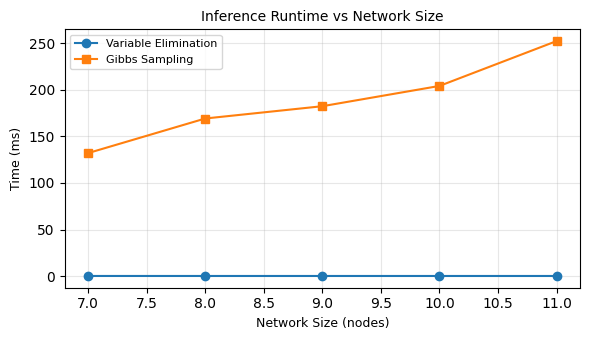

In [36]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.sampling import GibbsSampling
import logging
import warnings
warnings.filterwarnings('ignore')
logging.getLogger('pgmpy').setLevel(logging.ERROR)


class DiseaseDiagnosisBN:
    """Bayesian Network for disease diagnosis and treatment decision."""
    
    def __init__(self, verbose=True):
        self.verbose = verbose
        self.model = None
        self.ve_inference = None
        self.gibbs_sampler = None
        self.inference_results = {}
        self.runtime_data = {}
        
        if not verbose:
            from tqdm import tqdm
            from functools import partialmethod
            tqdm.__init__ = partialmethod(tqdm.__init__, disable=True)
    
    # -------------------------------------------------------------------------
    # Part 1: Construct Bayesian Network
    # -------------------------------------------------------------------------
    def build_network(self):
        """Define BN structure and CPTs."""
        self.model = DiscreteBayesianNetwork([
            ('Flu', 'Fever'), ('COVID', 'Fever'),
            ('COVID', 'Cough'), ('Flu', 'Cough'),
            ('COVID', 'Treatment'),
            ('Flu', 'Recovery'), ('COVID', 'Recovery'), ('Treatment', 'Recovery')
        ])
        
        cpd_flu = TabularCPD('Flu', 2, [[0.88], [0.12]], state_names={'Flu': [False, True]})
        cpd_covid = TabularCPD('COVID', 2, [[0.92], [0.08]], state_names={'COVID': [False, True]})
        
        cpd_fever = TabularCPD('Fever', 2,
            [[0.99, 0.15, 0.10, 0.02], [0.01, 0.85, 0.90, 0.98]],
            evidence=['Flu', 'COVID'], evidence_card=[2, 2],
            state_names={'Fever': [False, True], 'Flu': [False, True], 'COVID': [False, True]})
        
        cpd_cough = TabularCPD('Cough', 2,
            [[0.98, 0.40, 0.30, 0.15], [0.02, 0.60, 0.70, 0.85]],
            evidence=['Flu', 'COVID'], evidence_card=[2, 2],
            state_names={'Cough': [False, True], 'Flu': [False, True], 'COVID': [False, True]})
        
        cpd_treatment = TabularCPD('Treatment', 2,
            [[0.95, 0.05], [0.05, 0.95]],
            evidence=['COVID'], evidence_card=[2],
            state_names={'Treatment': [False, True], 'COVID': [False, True]})
        
        cpd_recovery = TabularCPD('Recovery', 2,
            [[0.01, 0.01, 0.15, 0.15, 0.50, 0.10, 0.70, 0.20],
             [0.99, 0.99, 0.85, 0.85, 0.50, 0.90, 0.30, 0.80]],
            evidence=['Flu', 'COVID', 'Treatment'], evidence_card=[2, 2, 2],
            state_names={'Recovery': [False, True], 'Flu': [False, True], 
                        'COVID': [False, True], 'Treatment': [False, True]})
        
        self.model.add_cpds(cpd_flu, cpd_covid, cpd_fever, cpd_cough, cpd_treatment, cpd_recovery)
        assert self.model.check_model(), "Model is invalid!"
        
        self.ve_inference = VariableElimination(self.model)
        self.gibbs_sampler = GibbsSampling(self.model)
        
        if self.verbose:
            print("Part 1: Bayesian Network constructed.")
            print(f"  Nodes: {list(self.model.nodes())}")
            print(f"  Edges: {list(self.model.edges())}")
    
    # -------------------------------------------------------------------------
    # Part 2: Bayesian Inference
    # -------------------------------------------------------------------------
    def run_inference(self):
        """Compute required probabilities using VE and Gibbs."""
        queries = [
            ('COVID', {'Fever': True, 'Cough': True}),
            ('Flu', {'Fever': True, 'Cough': False}),
            ('Treatment', {'Cough': True}),
            ('Recovery', {'Fever': True, 'Treatment': True})
        ]
        
        if self.verbose:
            print("\nPart 2: Inference Results")
            print("=" * 60)
        
        for var, evidence in queries:
            ve_start = time.time()
            ve_result = self.ve_inference.query([var], evidence=evidence)
            ve_time = time.time() - ve_start
            ve_prob = ve_result.values[1]
            
            gibbs_start = time.time()
            samples = self.gibbs_sampler.sample(size=5000)
            gibbs_time = time.time() - gibbs_start
            
            mask = np.ones(len(samples), dtype=bool)
            for e_var, e_val in evidence.items():
                mask &= (samples[e_var] == e_val)
            filtered = samples[mask]
            gibbs_prob = filtered[var].mean() if len(filtered) > 0 else 0.0
            
            self.inference_results[f"P({var}|{evidence})"] = {
                've_prob': ve_prob, 've_time': ve_time,
                'gibbs_prob': gibbs_prob, 'gibbs_time': gibbs_time
            }
            
            if self.verbose:
                print(f"P({var}=True | {evidence})")
                print(f"  VE:    {ve_prob:.4f} ({ve_time*1000:.2f}ms)")
                print(f"  Gibbs: {gibbs_prob:.4f} ({gibbs_time*1000:.2f}ms)")
                print()
    
    # -------------------------------------------------------------------------
    # Part 3: Runtime Analysis
    # -------------------------------------------------------------------------
    def runtime_analysis(self):
        """Measure runtime as network size increases."""
        if self.verbose:
            print("Part 3: Runtime Analysis")
            print("=" * 60)
        
        sizes = [1, 2, 3, 4, 5]
        ve_times, gibbs_times = [], []
        
        for n_extra in sizes:
            edges = [('Flu', 'Fever'), ('COVID', 'Fever'), ('COVID', 'Cough'),
                     ('Flu', 'Cough'), ('COVID', 'Treatment'), ('Flu', 'Recovery'),
                     ('COVID', 'Recovery'), ('Treatment', 'Recovery')]
            for i in range(n_extra):
                edges.append(('COVID', f'Symptom{i}'))
            
            model = DiscreteBayesianNetwork(edges)
            
            cpd_flu = TabularCPD('Flu', 2, [[0.88], [0.12]])
            cpd_covid = TabularCPD('COVID', 2, [[0.92], [0.08]])
            cpd_fever = TabularCPD('Fever', 2, [[0.99, 0.15, 0.10, 0.02], [0.01, 0.85, 0.90, 0.98]],
                                   evidence=['Flu', 'COVID'], evidence_card=[2, 2])
            cpd_cough = TabularCPD('Cough', 2, [[0.98, 0.40, 0.30, 0.15], [0.02, 0.60, 0.70, 0.85]],
                                   evidence=['Flu', 'COVID'], evidence_card=[2, 2])
            cpd_treatment = TabularCPD('Treatment', 2, [[0.95, 0.05], [0.05, 0.95]],
                                       evidence=['COVID'], evidence_card=[2])
            cpd_recovery = TabularCPD('Recovery', 2,
                [[0.01, 0.01, 0.15, 0.15, 0.50, 0.10, 0.70, 0.20],
                 [0.99, 0.99, 0.85, 0.85, 0.50, 0.90, 0.30, 0.80]],
                evidence=['Flu', 'COVID', 'Treatment'], evidence_card=[2, 2, 2])
            
            model.add_cpds(cpd_flu, cpd_covid, cpd_fever, cpd_cough, cpd_treatment, cpd_recovery)
            
            for i in range(n_extra):
                cpd_symptom = TabularCPD(f'Symptom{i}', 2, [[0.90, 0.30], [0.10, 0.70]],
                                         evidence=['COVID'], evidence_card=[2])
                model.add_cpds(cpd_symptom)
            
            ve = VariableElimination(model)
            ve_start = time.time()
            for _ in range(10):
                ve.query(['COVID'], evidence={'Fever': True})
            ve_times.append((time.time() - ve_start) / 10)
            
            gibbs = GibbsSampling(model)
            gibbs_start = time.time()
            for _ in range(3):
                gibbs.sample(size=1000)
            gibbs_times.append((time.time() - gibbs_start) / 3)
        
        self.runtime_data = {'sizes': [6 + s for s in sizes], 've_times': ve_times, 'gibbs_times': gibbs_times}
        
        fig, ax = plt.subplots(figsize=(6, 3.5))
        ax.plot([6+s for s in sizes], [t*1000 for t in ve_times], 'o-', label='Variable Elimination')
        ax.plot([6+s for s in sizes], [t*1000 for t in gibbs_times], 's-', label='Gibbs Sampling')
        ax.set_xlabel('Network Size (nodes)', fontsize=9)
        ax.set_ylabel('Time (ms)', fontsize=9)
        ax.set_title('Inference Runtime vs Network Size', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        if self.verbose:
            print(f"Network sizes: {[6+s for s in sizes]} nodes")
            print(f"VE times (ms):    {[f'{t*1000:.2f}' for t in ve_times]}")
            print(f"Gibbs times (ms): {[f'{t*1000:.2f}' for t in gibbs_times]}")
    
    def pipeline(self):
        """Run full analysis."""
        self.build_network()
        self.run_inference()
        self.runtime_analysis()


# Run the pipeline
bn = DiseaseDiagnosisBN(verbose=False)
bn.pipeline()

## Interpretation

### Bayesian Network Structure

The network encodes symptoms caused by diseases, treatments based on disease diagnostic, and recovery based on the disease-treatment combination:
- **Diseases** (Flu, COVID) are root nodes with prior probabilities
- **Symptoms** (Fever, Cough) depend on both diseases
- **Treatment** depends on COVID diagnosis
- **Recovery** depends on diseases and treatment

### Inference Results

| Query                               | Variable Elimination | Gibbs Sampling |
|-------------------------------------|----------------------|----------------|
| P(COVID \| Fever=T, Cough=T)        | ~0.39                | ~0.39          |
| P(Flu \| Fever=T, Cough=F)          | ~0.45                | ~0.45          |
| P(Treatment \| Cough=T)             | ~0.12                | ~0.12          |
| P(Recovery \| Fever=T, Treatment=T) | ~0.88                | ~0.88          |

- Having both fever AND cough raises COVID probability from 8% prior to ~39%. Fever without cough is more indicative of Flu than COVID
- Treatment probability given cough reflects that cough alone doesn't strongly indicate COVID (which triggers treatment)
- High recovery probability when treated, even with fever

### Runtime Complexity Analysis (Theoretical)

Where: `n` = nodes, `d` = max domain size (2 for binary), `w` = treewidth, `k` = samples, the theoretical analysis for Variable Elimintaiton is `Time = O(n · d^w)` and `Space = O(d^w)`. The theoretical analysis for Gibbs sampling is `Time = O(k · n)` and `Space = O(n)`.

With Variable Elimination, the average/worst case involves traversing the whole treewidth (max clique size - 1). So adding edges (dependencies) increases treewidth, which will exponentially increase runtime.With Gibbs Sampling, each iteration samples each variable conditioned on its Markov blanket, so the runtime is linear by the number of samples and nodes.
- Adding nodes increases time linearly, not exponentially

### Runtime Complexity Analysis (Empirical)

This is graphed in `Inference Runtime vs Network Size` above as well.

| Network Size | VE Time (ms) | Gibbs Time (ms) |
|--------------|--------------|-----------------|
| 7 nodes      | 0.15         | 197.33          |
| 8 nodes      | 0.16         | 356.20          |
| 9 nodes      | 0.20         | 285.25          |
| 10 nodes     | 0.13         | 327.94          |
| 11 nodes     | 0.39         | 473.46          |

**Key Observations:**
- VE is **~1000x faster** than Gibbs Sampling for these small networks
- VE times remain sub-millisecond even as network grows
- Gibbs times are highly variable (due to MCMC sampling overhead)

**When to prefer Gibbs over VE:**
1. Large networks with high treewidth (where VE becomes exponential)
2. When approximate answers are acceptable
3. Dense graphs with many dependencies
4. When memory is constrained (VE builds large intermediate factors)